<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 04</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Problem framing</div><div style="font-size:1.05em;opacity:0.85">Turning "stopped buying" into a label we can learn — and trust.</div></div>

Stage 03 showed *how* customers buy; this stage decides *what counts as churn*. In a
non-contractual business nobody cancels: a customer is simply silent, and silence is ambiguous.
A monthly buyer silent for 90 days has probably left; a customer who buys twice a year has
not. The label has to respect each customer's own rhythm, and it has to be computable at a date
without looking into the future.

**Pipeline rule.** The definitions live in `churnvalue.snapshots` (cutoffs, eligibility,
labels) and `churnvalue.splits` (temporal split); this notebook calls them — with the
parameters from `configs/default.yaml` — and shows why each choice was made.

| | |
|---|---|
| **Input** | `data/interim/transactions.parquet` · `data/interim/snapshots.parquet` |
| **Outputs** | `reports/results/04_summary.json` · `reports/figures/04_*.png` |
| **Parameters** | `configs/default.yaml` → `snapshots` (H = 90 d, f = 0.5, 6 months of history), `splits` |
| **Shared code** | `churnvalue.snapshots` · `churnvalue.splits` · `churnvalue.features` · `churnvalue.viz.style` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">P1 the label</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">P2 the calendar</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">P3 eligibility</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">P4 churn by cutoff</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">P5 label sanity</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">P6 the split</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

**Colour convention.** From this stage on, **red is a churner** — only ever that. Slate is an
active customer or a neutral magnitude; grey is context or an excluded customer.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch

from churnvalue.config import load_config, project_root
from churnvalue.features import add_derived_features, compute_base_features, purchase_days
from churnvalue.reporting import StageSummary
from churnvalue.snapshots import churn_labels, eligible_mask, make_cutoffs
from churnvalue.splits import make_temporal_split
from churnvalue.viz import style
from churnvalue.viz.style import CHURN, GRID, INK, MUTED, NEUTRAL, RETAINED

os.chdir(project_root())
CFG = load_config()
SNAP = CFG.snapshots
H, F = SNAP.horizon_days, SNAP.eligibility_f
STAGE, FIGURES, RESULTS = "04", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


tx = pd.read_parquet(CFG.data.interim_dir / "transactions.parquet")
snapshots = pd.read_parquet(CFG.data.interim_dir / "snapshots.parquet")
cutoffs = make_cutoffs(tx["date"].min(), tx["date"].max(), H, SNAP.min_history_months)
split = make_temporal_split(cutoffs, H, CFG.splits.calibration_offset_months)
S["horizon_days"], S["eligibility_f"] = H, F
S["n_cutoffs"] = len(cutoffs)
S["first_cutoff"], S["last_cutoff"] = cutoffs[0], cutoffs[-1]


def features_at(cutoff):
    """All customers known at the cutoff (no eligibility filter), with derived features."""
    base = compute_base_features(tx, cutoff, H)
    return add_derived_features(base, H, SNAP.cadence_floor_days)

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">P1 · The label</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">silence only means something relative to a customer's rhythm</span></div>

At a **cutoff** *t* the model may see everything up to *t* and nothing after. For each customer:

- **cadence** = (last purchase − first purchase) / (purchase days − 1), their usual gap;
- **expected next purchase** *E* = last purchase + cadence;
- the customer is **eligible** if they have at least two purchase days and *E* falls in the
  window [*t* − f·H, *t* + H + f·H] — they *should* buy around the horizon;
- an eligible customer is a **churner** if they make no purchase in (*t*, *t* + H].

This is the *expected next purchase window* of the project this work grew from, made
parameterised and testable. Eligibility is what makes silence informative: it removes customers
whose rhythm is too slow for the horizon to say anything (*E* after the window) and customers
who were already long gone (*E* well before *t*). Five real customers at the test cutoff:

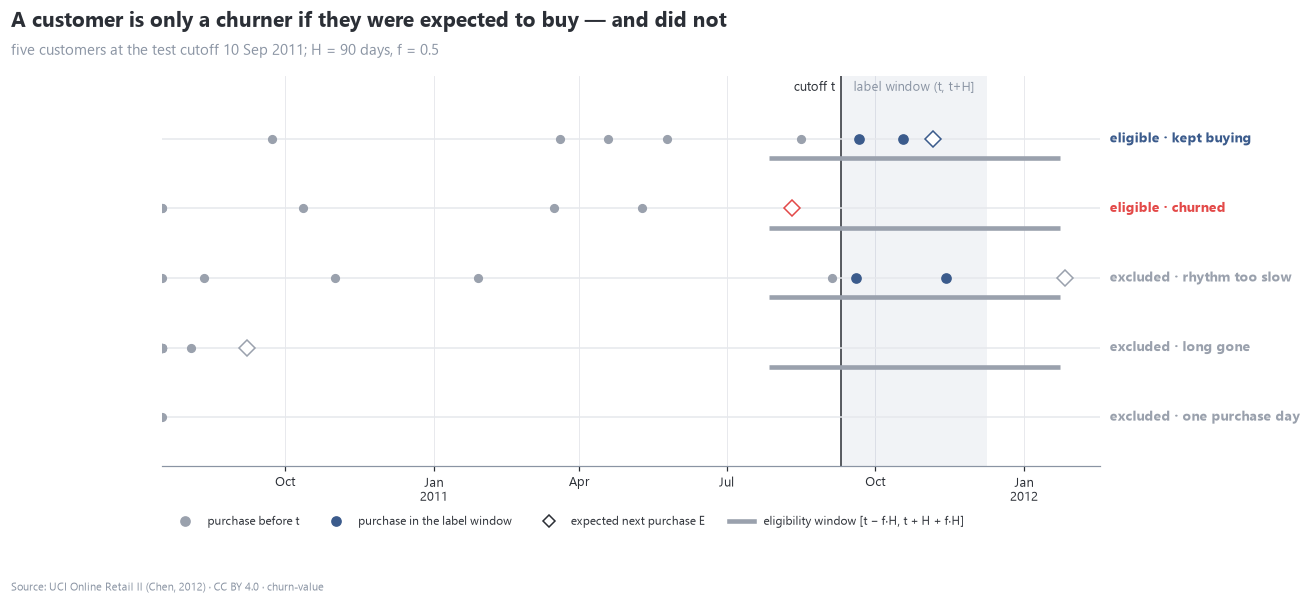

In [2]:
t = split.test
at_t = features_at(t)
at_t["days_to_expected"] = at_t["cadence_days"] - at_t["recency_days"]
at_t["eligible"] = eligible_mask(at_t, H, F)
at_t["churn"] = churn_labels(tx, at_t.index, t, H)
lo, hi = -F * H, H + F * H
mid = at_t["n_purchase_days"].between(5, 12)
examples = {
    "eligible · kept buying": at_t[at_t["eligible"] & (at_t["churn"] == 0) & mid],
    "eligible · churned": at_t[at_t["eligible"] & (at_t["churn"] == 1) & mid],
    "excluded · rhythm too slow": at_t[
        (at_t["days_to_expected"] > hi) & at_t["n_purchase_days"].between(3, 6)
    ],
    "excluded · long gone": at_t[
        (at_t["days_to_expected"] < lo) & at_t["n_purchase_days"].between(3, 8)
    ],
    "excluded · one purchase day": at_t[at_t["n_purchase_days"] == 1],
}
chosen = {label: frame.index[len(frame) // 2] for label, frame in examples.items()}
days = purchase_days(tx)

fig, ax = plt.subplots(figsize=(11, 4.6))
start, stop = t - pd.Timedelta(days=420), t + pd.Timedelta(days=int(hi) + 25)
ax.axvspan(t, t + pd.Timedelta(days=H), color=NEUTRAL, alpha=0.07, lw=0)
ax.axvline(t, color=INK, lw=1)
ax.text(
    t - pd.Timedelta(days=4),
    len(chosen) - 0.35,
    "cutoff t",
    ha="right",
    fontsize=8.5,
    color=INK,
    va="bottom",
)
ax.text(
    t + pd.Timedelta(days=H / 2),
    len(chosen) - 0.35,
    "label window (t, t+H]",
    ha="center",
    fontsize=8.5,
    color=MUTED,
    va="bottom",
)
for row, (label, customer) in enumerate(reversed(list(chosen.items()))):
    c = at_t.loc[customer]
    history = days[(days["customer_id"] == customer)]
    past = history[history["date"] <= t]
    future = history[(history["date"] > t) & (history["date"] <= t + pd.Timedelta(days=H))]
    outcome_color = CHURN if "churned" in label else NEUTRAL if "kept" in label else RETAINED
    ax.hlines(row, start, stop, color=GRID, lw=1)
    if c["n_purchase_days"] >= 2:
        expected = t + pd.Timedelta(days=float(c["days_to_expected"]))
        ax.plot(
            [t + pd.Timedelta(days=lo), t + pd.Timedelta(days=hi)],
            [row - 0.28] * 2,
            color=RETAINED,
            lw=3,
            solid_capstyle="butt",
        )
        ax.plot(
            expected, row, "D", color="white", markeredgecolor=outcome_color, markersize=7, zorder=4
        )
    ax.plot(
        past["date"].clip(lower=start),
        [row] * len(past),
        "o",
        color=RETAINED,
        markersize=5,
        zorder=3,
    )
    ax.plot(future["date"], [row] * len(future), "o", color=NEUTRAL, markersize=6, zorder=3)
    ax.text(
        stop + pd.Timedelta(days=6),
        row,
        label,
        va="center",
        fontsize=9,
        color=outcome_color,
        fontweight="bold",
    )
ax.set_yticks([])
ax.set_xlim(start, stop)
ax.set_ylim(-0.7, len(chosen) - 0.1)
ax.spines["left"].set_visible(False)
ax.plot([], [], "o", color=RETAINED, label="purchase before t")
ax.plot([], [], "o", color=NEUTRAL, label="purchase in the label window")
ax.plot([], [], "D", color="white", markeredgecolor=INK, label="expected next purchase E")
ax.plot([], [], color=RETAINED, lw=3, label="eligibility window [t − f·H, t + H + f·H]")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.1), ncol=4, fontsize=8)
style.date_axis(ax)
style.headline(
    fig,
    "A customer is only a churner if they were expected to buy — and did not",
    f"five customers at the test cutoff {t:%d %b %Y}; H = {H} days, f = {F}",
)
style.add_source(fig, y=-0.12)
save(fig, "label_examples")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">P2 · The calendar</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">sixteen snapshots, each with a closed label window</span></div>

One snapshot per month. The newest cutoff is the last day of data minus H, so every label
window is fully observed; the oldest keeps six months of history for the features. The same
customer appears in many snapshots — which is why the split (P6) is by time, never by row.

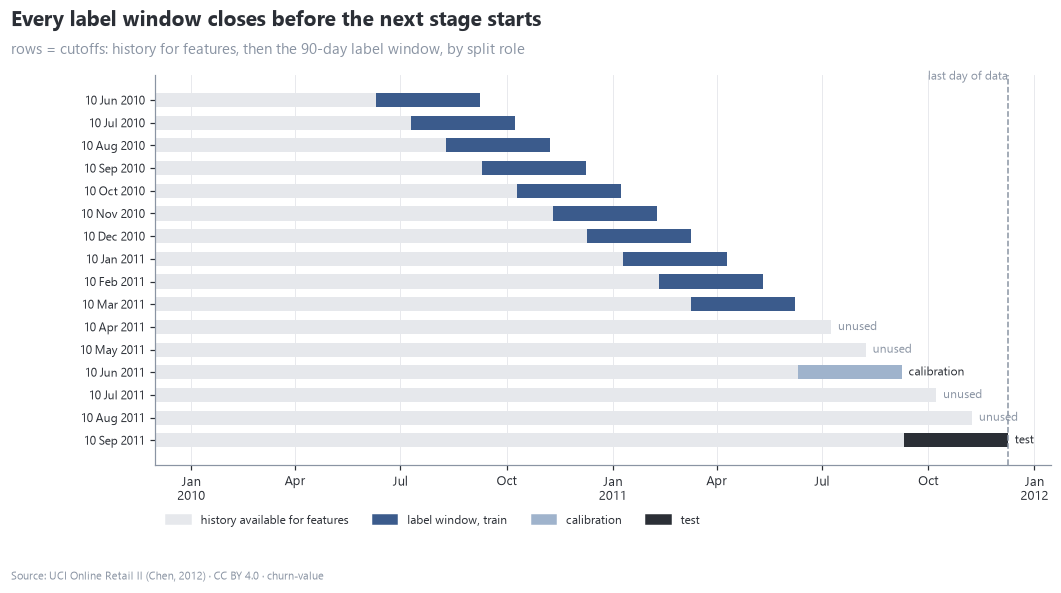

In [3]:
role = {c: "train" for c in split.train}
role[split.calibration], role[split.test] = "calibration", "test"
role_color = {"train": NEUTRAL, "calibration": "#9FB3CC", "test": INK, "unused": GRID}
fig, ax = plt.subplots(figsize=(10.5, 4.6))
data_start = tx["date"].min()
for i, c in enumerate(cutoffs):
    r = role.get(c, "unused")
    ax.barh(i, (c - data_start).days, left=data_start, color=GRID, height=0.62)
    ax.barh(i, H, left=c, color=role_color[r], height=0.62)
    ax.text(
        c + pd.Timedelta(days=H + 6),
        i,
        r if r != "train" else "",
        va="center",
        fontsize=8,
        color=INK if r != "unused" else MUTED,
    )
ax.set_yticks(range(len(cutoffs)), [f"{c:%d %b %Y}" for c in cutoffs], fontsize=8)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.axvline(tx["date"].max(), color=MUTED, lw=1, ls="--")
ax.text(tx["date"].max(), -0.9, "last day of data", ha="right", fontsize=8, color=MUTED)
handles = [
    Patch(color=color, label=label)
    for label, color in [
        ("history available for features", GRID),
        ("label window, train", NEUTRAL),
        ("calibration", "#9FB3CC"),
        ("test", INK),
    ]
]
ax.legend(handles=handles, loc="upper left", ncol=4, bbox_to_anchor=(0, -0.1), fontsize=8)
style.date_axis(ax)
S["n_train_cutoffs"] = len(split.train)
S["unused_cutoffs"] = [c for c in cutoffs if c not in role]
style.headline(
    fig,
    "Every label window closes before the next stage starts",
    "rows = cutoffs: history for features, then the 90-day label window, by split role",
)
style.add_source(fig, y=-0.1)
save(fig, "calendar")
plt.show()

Four cutoffs are deliberately **unused**. April and May 2011 have label windows that run past
the calibration cutoff, so training on them would show the model the period it is calibrated
on; July and August 2011 overlap the test cutoff in the same way. Leakage-safety costs data.

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">P3 · Eligibility</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">who enters the problem, and how sensitive that is to f</span></div>

The funnel narrows twice at each cutoff: to repeat customers (a cadence exists) and then to
those expected to buy around the horizon. The window width f is a modelling choice, so the
second panel re-runs the label with f ∈ {0.25, 0.5, 1.0}: wider windows admit more customers
whose silence is less informative, and the churn rate drifts with them.

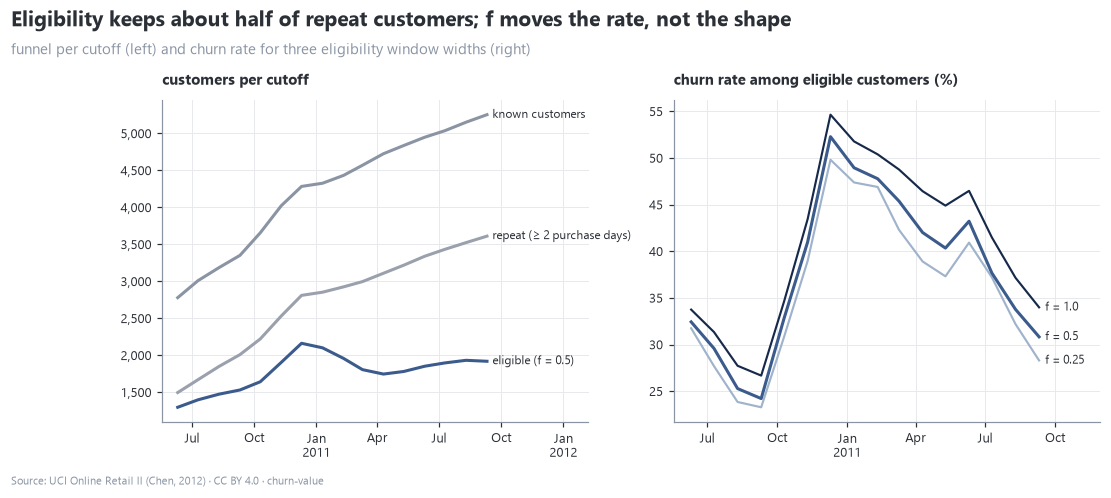

In [4]:
rows, sensitivity = [], []
for c in cutoffs:
    feats = features_at(c)
    labels = churn_labels(tx, feats.index, c, H)
    rows.append(
        {
            "cutoff": c,
            "known customers": len(feats),
            "repeat (≥ 2 purchase days)": int((feats["n_purchase_days"] >= 2).sum()),
            "eligible (f = 0.5)": int(eligible_mask(feats, H, F).sum()),
            "naive churn rate": labels[feats["n_purchase_days"] >= 2].mean(),
        }
    )
    for f in (0.25, 0.5, 1.0):
        mask = eligible_mask(feats, H, f)
        sensitivity.append(
            {"cutoff": c, "f": f, "eligible": int(mask.sum()), "churn_rate": labels[mask].mean()}
        )
funnel = pd.DataFrame(rows).set_index("cutoff")
sens = pd.DataFrame(sensitivity)
assert (funnel["eligible (f = 0.5)"].values == snapshots.groupby("cutoff").size().values).all()
eligible = funnel["eligible (f = 0.5)"]
S["eligible_range"] = [int(eligible.min()), int(eligible.max())]
S["eligible_share_of_repeat_test"] = (
    eligible[split.test] / funnel.loc[split.test, "repeat (≥ 2 purchase days)"]
)
S["f_sensitivity_test"] = sens[sens["cutoff"] == split.test].set_index("f").to_dict(orient="index")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
shades = {
    "known customers": GRID,
    "repeat (≥ 2 purchase days)": RETAINED,
    "eligible (f = 0.5)": NEUTRAL,
}
for column, color in shades.items():
    ax1.plot(funnel.index, funnel[column], color=color if color != GRID else MUTED, lw=2)
    ax1.text(
        funnel.index[-1] + pd.Timedelta(days=8),
        funnel[column].iloc[-1],
        column,
        va="center",
        fontsize=8,
        color=INK,
    )
ax1.set_title("customers per cutoff", fontsize=10)
ax1.set_xlim(None, funnel.index[-1] + pd.Timedelta(days=150))
ax1.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ramp = {0.25: "#9FB3CC", 0.5: NEUTRAL, 1.0: "#16294A"}
for f, color in ramp.items():
    part = sens[sens["f"] == f].set_index("cutoff")
    ax2.plot(part.index, part["churn_rate"] * 100, color=color, lw=2 if f == F else 1.4)
    ax2.text(
        part.index[-1] + pd.Timedelta(days=8),
        part["churn_rate"].iloc[-1] * 100,
        f"f = {f}",
        va="center",
        fontsize=8,
        color=INK,
    )
ax2.set_title("churn rate among eligible customers (%)", fontsize=10)
ax2.set_xlim(None, sens["cutoff"].max() + pd.Timedelta(days=80))
for ax in (ax1, ax2):
    style.date_axis(ax)
style.headline(
    fig,
    "Eligibility keeps about half of repeat customers; f moves the rate, not the shape",
    "funnel per cutoff (left) and churn rate for three eligibility window widths (right)",
)
style.add_source(fig)
save(fig, "eligibility")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">P4 · Churn by cutoff</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the central risk: the base rate moves with the season</span></div>

The churn rate among eligible customers is not stable. It more than doubles between the
early-autumn cutoffs and the December cutoff, whose label window is the quiet post-Christmas
quarter. A model calibrated on one season and used in another will be wrong about *how many*
customers churn even if it ranks them well — and the retention economics act on exactly that
number. This single chart is why the project reports calibration on the test cutoff as a
first-class result, and why stage 05 adds features describing the season.

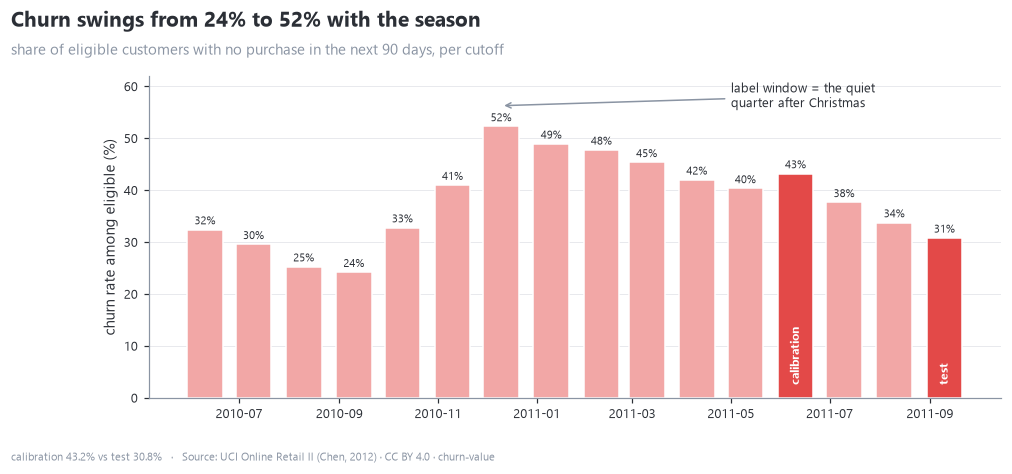

In [5]:
rate = snapshots.groupby("cutoff")["churn"].agg(["mean", "size"])
S["churn_rate_by_cutoff"] = rate["mean"].to_dict()
S["churn_rate_min"], S["churn_rate_max"] = rate["mean"].min(), rate["mean"].max()
S["churn_rate_calibration"] = rate.loc[split.calibration, "mean"]
S["churn_rate_test"] = rate.loc[split.test, "mean"]

fig, ax = plt.subplots(figsize=(10, 3.8))
colors = [CHURN if c in (split.calibration, split.test) else "#F2A7A6" for c in rate.index]
ax.bar(rate.index, rate["mean"] * 100, width=22, color=colors, edgecolor="white")
for c, row in rate.iterrows():
    ax.text(c, row["mean"] * 100 + 1, f"{row['mean']:.0%}", ha="center", fontsize=7.5, color=INK)
for c, label in [(split.calibration, "calibration"), (split.test, "test")]:
    ax.text(c, 3, label, ha="center", rotation=90, fontsize=8, color="white", fontweight="bold")
peak = rate["mean"].idxmax()
ax.annotate(
    "label window = the quiet\nquarter after Christmas",
    xy=(peak, rate.loc[peak, "mean"] * 100 + 4),
    xytext=(pd.Timestamp("2011-05-01"), 56),
    fontsize=8.5,
    color=INK,
    arrowprops={"arrowstyle": "->", "color": MUTED, "lw": 1},
)
ax.set_ylabel("churn rate among eligible (%)")
ax.set_ylim(0, 62)
ax.grid(axis="x", visible=False)
style.headline(
    fig,
    f"Churn swings from {S['churn_rate_min']:.0%} to {S['churn_rate_max']:.0%} with the season",
    f"share of eligible customers with no purchase in the next {H} days, per cutoff",
)
style.add_source(
    fig, f"calibration {S['churn_rate_calibration']:.1%} vs test {S['churn_rate_test']:.1%}"
)
save(fig, "churn_by_cutoff")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">P5 · Label sanity</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">does the label behave like churn?</span></div>

Two checks. **Cleanliness**: the naive label (every repeat customer, no eligibility window)
should show a higher churn rate, because it counts slow-rhythm customers whose silence is simply
their normal gap. **Lateness**: being cycles late is the intuitive sign of churn (stage 03, E7
found a quarter of repeat customers two cycles late) — but what remains of that signal *inside*
the eligible population, which was selected on it?

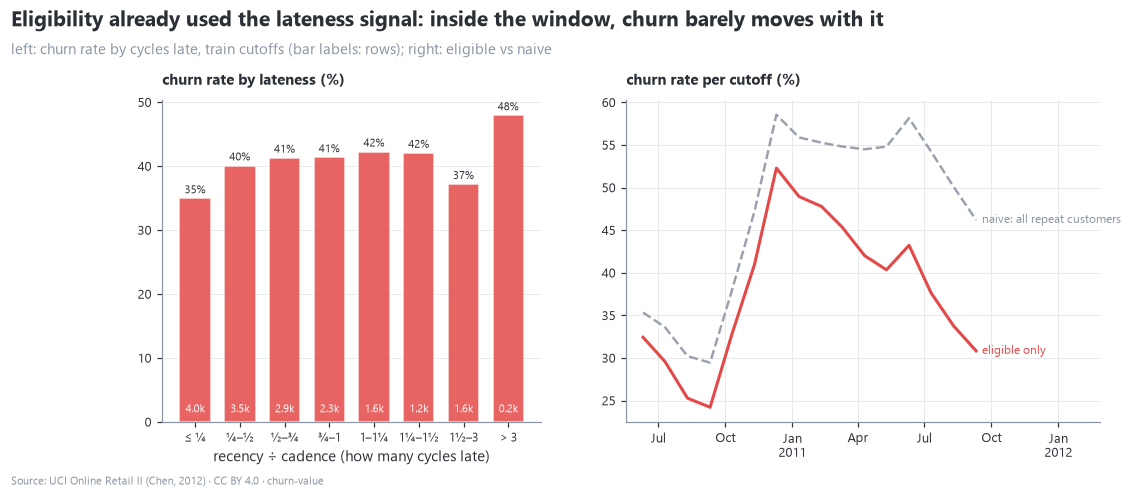

In [6]:
train = snapshots[snapshots["cutoff"].isin(split.train)]
buckets = pd.cut(
    train["overdue_ratio"], [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 3, np.inf], include_lowest=True
)
mono = train.groupby(buckets, observed=True)["churn"].agg(["mean", "size"])
S["churn_by_overdue_bucket"] = {str(k): v for k, v in mono["mean"].items()}
deciles = train.groupby(pd.qcut(train["overdue_ratio"], 10, duplicates="drop"), observed=True)
S["lateness_decile_churn_range"] = [deciles["churn"].mean().min(), deciles["churn"].mean().max()]
S["beyond_3_cycles"] = {
    "share": (train["overdue_ratio"] > 3).mean(),
    "churn_rate": train.loc[train["overdue_ratio"] > 3, "churn"].mean(),
}
S["naive_minus_eligible_mean"] = (funnel["naive churn rate"] - rate["mean"]).mean()
S["lateness_churn_range"] = [mono["mean"].min(), mono["mean"].max()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.25]})
x = np.arange(len(mono))
ax1.bar(x, mono["mean"] * 100, color=CHURN, alpha=0.85, width=0.7, edgecolor="white")
ax1.set_xticks(x, ["≤ ¼", "¼–½", "½–¾", "¾–1", "1–1¼", "1¼–1½", "1½–3", "> 3"], fontsize=8)
ax1.set_xlabel("recency ÷ cadence (how many cycles late)")
ax1.set_title("churn rate by lateness (%)", fontsize=10)
for xi, (v, size) in enumerate(zip(mono["mean"], mono["size"], strict=True)):
    ax1.text(xi, 1.5, f"{size / 1e3:.1f}k", ha="center", fontsize=7, color="white")
    ax1.text(xi, v * 100 + 0.8, f"{v:.0%}", ha="center", fontsize=7.5, color=INK)
ax1.grid(axis="x", visible=False)
ax2.plot(funnel.index, funnel["naive churn rate"] * 100, color=RETAINED, lw=1.6, ls="--")
ax2.plot(rate.index, rate["mean"] * 100, color=CHURN, lw=2)
ax2.text(
    funnel.index[-1] + pd.Timedelta(days=8),
    funnel["naive churn rate"].iloc[-1] * 100,
    "naive: all repeat customers",
    va="center",
    fontsize=8,
    color=MUTED,
)
ax2.text(
    rate.index[-1] + pd.Timedelta(days=8),
    rate["mean"].iloc[-1] * 100,
    "eligible only",
    va="center",
    fontsize=8,
    color=CHURN,
)
ax2.set_xlim(None, rate.index[-1] + pd.Timedelta(days=170))
ax2.set_title("churn rate per cutoff (%)", fontsize=10)
style.date_axis(ax2)
style.headline(
    fig,
    "Eligibility already used the lateness signal: inside the window, churn barely moves with it",
    "left: churn rate by cycles late, train cutoffs (bar labels: rows); right: eligible vs naive",
)
style.add_source(fig)
save(fig, "label_sanity")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">P6 · The split</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">by time, never by row</span></div>

Training uses the cutoffs whose label windows close before the calibration cutoff; calibration
uses one cutoff; the test is the newest cutoff. Tuning (stage 07) uses rolling-origin folds inside
the training cutoffs with the same rule, so no label window ever overlaps a later stage.

In [7]:
parts = {"train": list(split.train), "calibration": [split.calibration], "test": [split.test]}
split_table = pd.DataFrame(
    {
        name: {
            "cutoffs": (
                f"{min(cs):%b %Y} – {max(cs):%b %Y}" if len(cs) > 1 else f"{cs[0]:%d %b %Y}"
            ),
            "rows": int(snapshots["cutoff"].isin(cs).sum()),
            "customers": snapshots.loc[snapshots["cutoff"].isin(cs), "customer_id"].nunique(),
            "churn rate": snapshots.loc[snapshots["cutoff"].isin(cs), "churn"].mean(),
        }
        for name, cs in parts.items()
    }
).T
S["split"] = split_table.to_dict(orient="index")
display(split_table.style.format({"rows": "{:,}", "customers": "{:,}", "churn rate": "{:.1%}"}))

,cutoffs,rows,customers,churn rate
train,Jun 2010 – Mar 2011,"17,283","2,836",39.4%
calibration,10 Jun 2011,"1,853","1,853",43.2%
test,10 Sep 2011,"1,920","1,920",30.8%


<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">04 → 05, 06</span></div>

**Produced** — `reports/results/04_summary.json` and the figures `04_label_examples`,
`04_calendar`, `04_eligibility`, `04_churn_by_cutoff`, `04_label_sanity`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>The eligible label is cleaner than the naive one (9 points lower churn on average), and it absorbs the lateness signal: across lateness deciles inside the window, churn stays between 34 % and 43 %; only the 1 % more than three cycles late churn more (48 %). A lateness rule alone will be a weak model (stage 06).</li><li>The churn base rate swings with the season (24 % to 52 % across cutoffs; 43 % at calibration vs 31 % at test). Calibration is the central risk of this project.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>Churn = no purchase in the 90 days after the cutoff, among repeat customers expected to buy within [t − 45 d, t + 135 d] (f = 0.5).</li><li>Sixteen monthly cutoffs; split by time into 10 training cutoffs, one calibration cutoff and one test cutoff; the four cutoffs whose label windows would overlap a later stage are left unused.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>05_feature_engineering</b> — features computed strictly before each cutoff, plus features that describe the season.</li><li><b>06_baselines</b> — how far unsupervised customer-base models get on this label, and what their calibration costs.</li></ul></div>

In [8]:
S.write(RESULTS)

WindowsPath('reports/results/04_summary.json')